# XGBC 05 — Evaluation

Evaluate saved validation predictions without retraining the classifier.

In [1]:
# Import libraries
from pathlib import Path
import sys

In [2]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "peak_risk" / "xgboost"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "peak_risk" / "xgboost"

REPORTS_DIR, OUTPUTS_DIR


(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/peak_risk/xgboost'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/peak_risk/xgboost'))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)


In [4]:
# Get metrics
global_metrics = pd.read_csv(REPORTS_DIR / "XGBC_05_global_metrics.csv")
fold_metrics = pd.read_csv(REPORTS_DIR / "XGBC_05_fold_metrics.csv")
fsa_metrics = pd.read_csv(REPORTS_DIR / "XGBC_05_fsa_metrics.csv")
horizon_metrics = pd.read_csv(REPORTS_DIR / "XGBC_05_horizon_metrics.csv")
class_balance = pd.read_csv(REPORTS_DIR / "XGBC_05_class_balance.csv")
threshold_analysis = pd.read_csv(REPORTS_DIR / "XGBC_05_threshold_analysis.csv")
feature_importance = pd.read_csv(REPORTS_DIR / "XGBC_06_feature_importance.csv")

predictions = pd.read_parquet(
    OUTPUTS_DIR / "xgboost_classifier_validation_predictions.parquet"
)
predictions["forecast_origin"] = pd.to_datetime(predictions["forecast_origin"])
predictions["target_timestamp"] = pd.to_datetime(predictions["target_timestamp"])




In [5]:
# Display Global Metrics
display(global_metrics)


,model,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,xgboost_classifier,0.59633,0.459057,0.518766,0.716962,2519424,7.482544,5.760086,0.050577,0.556495,0.91758


In [6]:
# Display Fold Metrics
display(fold_metrics)


,fold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,0.738489,0.326038,0.452361,0.655909,1257984,10.965243,4.841079,0.071861,0.612423,0.915251
1,fold_2024,0.493535,0.821852,0.616720,0.893313,1261440,4.009386,6.676576,0.029352,0.670904,0.978510


In [7]:
# Display FSA Metrics
display(fsa_metrics)


,fold,fsa,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,L4T,0.371988,0.515311,0.432074,0.749230,209664,1.900183,2.632307,0.019902,0.426745,0.940723
1,fold_2023,M5R,0.492334,0.560078,0.524025,0.774239,209664,1.968864,2.239774,0.014778,0.533601,0.971104
2,fold_2023,M5S,0.388779,0.709239,0.502245,0.845671,209664,1.579670,2.881754,0.015996,0.591461,0.977289
3,fold_2023,M6G,0.713675,0.471081,0.567541,0.729962,209664,5.574634,3.679697,0.031422,0.641754,0.945781
4,fold_2023,M9R,0.506370,0.535375,0.520469,0.758604,209664,3.363954,3.556643,0.024936,0.541608,0.948749
5,fold_2023,M9W,0.983272,0.268872,0.422275,0.632017,209664,51.404151,14.056300,0.324131,0.914292,0.910618
6,fold_2024,L4T,0.521000,0.854422,0.647298,0.915910,210240,2.796804,4.586663,0.018747,0.733852,0.988222
7,fold_2024,M5R,0.354132,0.852608,0.500416,0.913034,210240,1.678082,4.040145,0.020448,0.600800,0.987151
8,fold_2024,M5S,0.390150,0.776611,0.519377,0.879946,210240,1.358447,2.704053,0.014131,0.533684,0.987667
9,fold_2024,M6G,0.451280,0.856583,0.591130,0.908611,210240,3.641553,6.912100,0.031369,0.675241,0.978770


In [8]:
# Display Horizon Metrics
display(horizon_metrics)

,fold,horizon,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,fold_2023,1,0.879661,0.361484,0.512403,0.677699,52416,10.956578,4.502442,0.063546,0.760591,0.955629
1,fold_2023,2,0.863977,0.361658,0.509881,0.677326,52416,10.956578,4.586386,0.064302,0.745952,0.952781
2,fold_2023,3,0.857082,0.352951,0.500000,0.672855,52416,10.956578,4.511981,0.065206,0.734952,0.950218
3,fold_2023,4,0.857700,0.383075,0.529610,0.687627,52416,10.956578,4.893544,0.062449,0.741374,0.951984
4,fold_2023,5,0.847862,0.359046,0.504465,0.675559,52416,10.956578,4.639805,0.065130,0.715137,0.944930
5,fold_2023,6,0.839901,0.356260,0.500306,0.673952,52416,10.956578,4.647436,0.065390,0.702404,0.940297
6,fold_2023,7,0.808326,0.341459,0.480108,0.665748,52416,10.956578,4.628358,0.067852,0.667832,0.928717
7,fold_2023,8,0.783604,0.327877,0.462313,0.658368,52416,10.956578,4.584478,0.069641,0.643583,0.921238
8,fold_2023,9,0.758579,0.331012,0.460904,0.659025,52416,10.956578,4.780983,0.070831,0.624576,0.914715
9,fold_2023,10,0.753678,0.312206,0.441517,0.649825,52416,10.956578,4.538690,0.072304,0.611576,0.913588


## Precision-Recall Curve

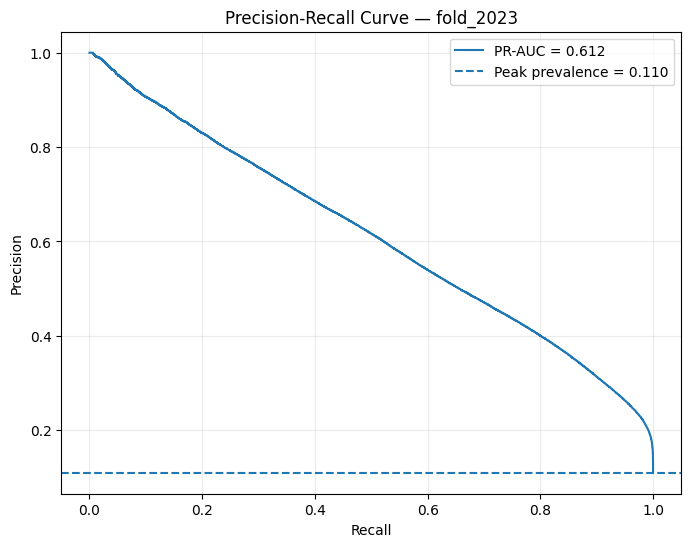

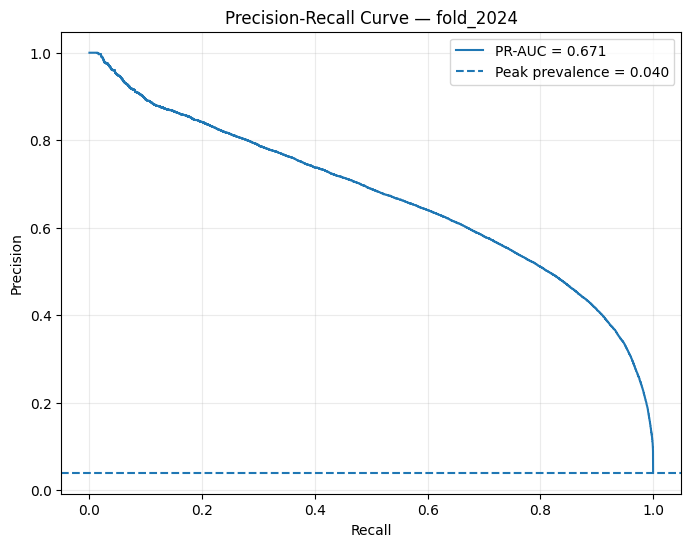

In [9]:
# Precision-Recall curve by validation fold.

for fold, group in predictions.groupby("fold", observed=True):
    precision, recall, _ = precision_recall_curve(
        group["actual"],
        group["probability"],
    )

    pr_auc = average_precision_score(
        group["actual"],
        group["probability"],
    )

    prevalence = group["actual"].mean()

    plt.figure(figsize=(8, 6))
    plt.plot(
        recall,
        precision,
        label=f"PR-AUC = {pr_auc:.3f}",
    )
    plt.axhline(
        prevalence,
        linestyle="--",
        label=f"Peak prevalence = {prevalence:.3f}",
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## ROC Curve

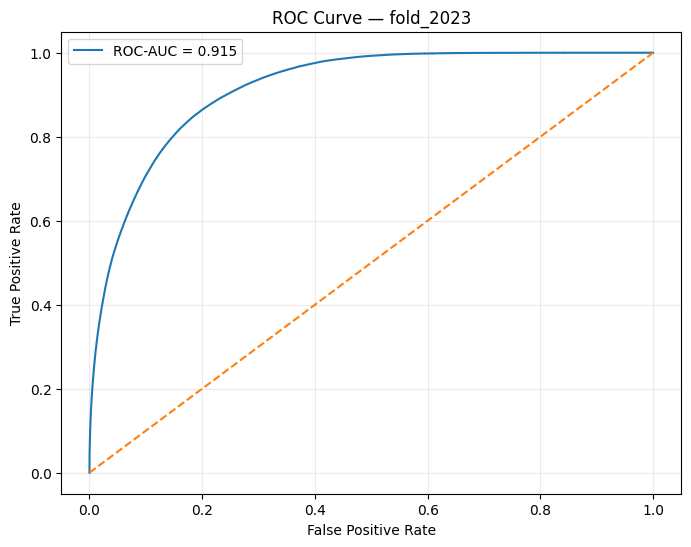

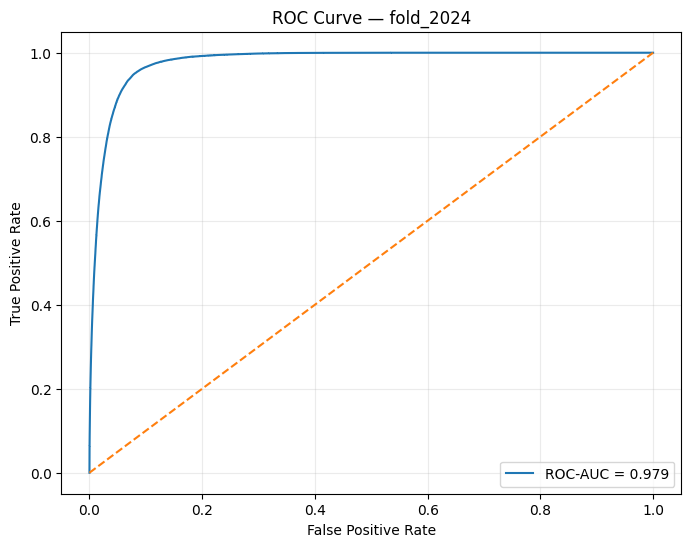

In [10]:
# ROC curve by validation fold.

for fold, group in predictions.groupby("fold", observed=True):
    fpr, tpr, _ = roc_curve(
        group["actual"],
        group["probability"],
    )

    roc_auc = roc_auc_score(
        group["actual"],
        group["probability"],
    )

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr,
        label=f"ROC-AUC = {roc_auc:.3f}",
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
    )
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## Confusion Matrix at Official Threshold 0.50

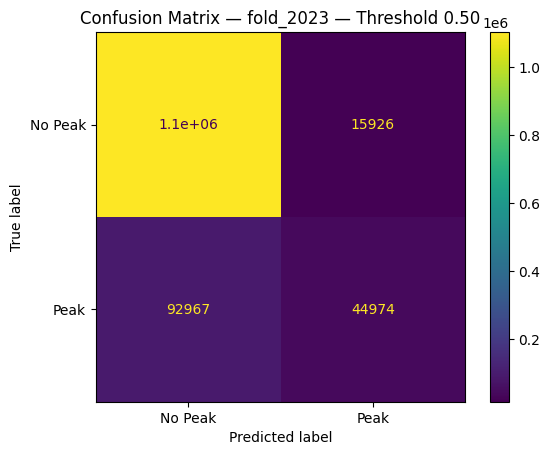

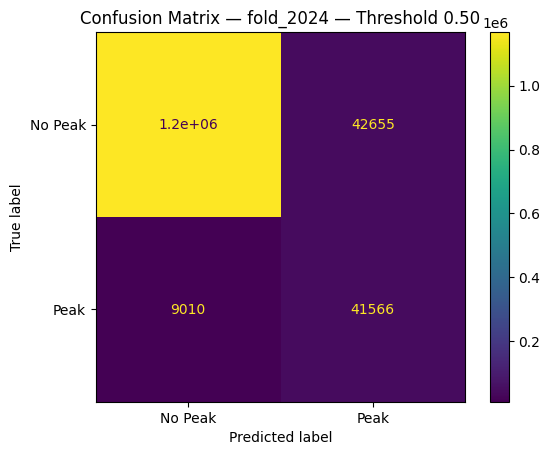

In [11]:
# Confusion matrix by fold at the common comparison threshold.

for fold, group in predictions.groupby("fold", observed=True):
    matrix = confusion_matrix(
        group["actual"],
        group["predicted"],
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No Peak", "Peak"],
    )

    display_matrix.plot()
    plt.title(f"Confusion Matrix — {fold} — Threshold 0.50")
    plt.show()


## Threshold Diagnostics

,threshold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,predicted_positive_rate_pct,brier_score,pr_auc,roc_auc
0,0.05,0.369114,0.721484,0.488374,0.810875,2519424,7.482544,14.625645,0.050577,0.556495,0.91758
1,0.10,0.419544,0.660948,0.513279,0.793495,2519424,7.482544,11.787972,0.050577,0.556495,0.91758
2,0.15,0.453886,0.623111,0.525203,0.781238,2519424,7.482544,10.272308,0.050577,0.556495,0.91758
3,0.20,0.480338,0.592806,0.530679,0.770468,2519424,7.482544,9.234531,0.050577,0.556495,0.91758
4,0.25,0.502922,0.566453,0.532800,0.760586,2519424,7.482544,8.427760,0.050577,0.556495,0.91758
5,0.30,0.522950,0.543070,0.532821,0.751502,2519424,7.482544,7.770427,0.050577,0.556495,0.91758
6,0.35,0.542629,0.521476,0.531842,0.742963,2519424,7.482544,7.190850,0.050577,0.556495,0.91758
7,0.40,0.560732,0.500268,0.528777,0.734286,2519424,7.482544,6.675693,0.050577,0.556495,0.91758
8,0.45,0.578586,0.479591,0.524458,0.725670,2519424,7.482544,6.202291,0.050577,0.556495,0.91758
9,0.50,0.596330,0.459057,0.518766,0.716962,2519424,7.482544,5.760086,0.050577,0.556495,0.91758


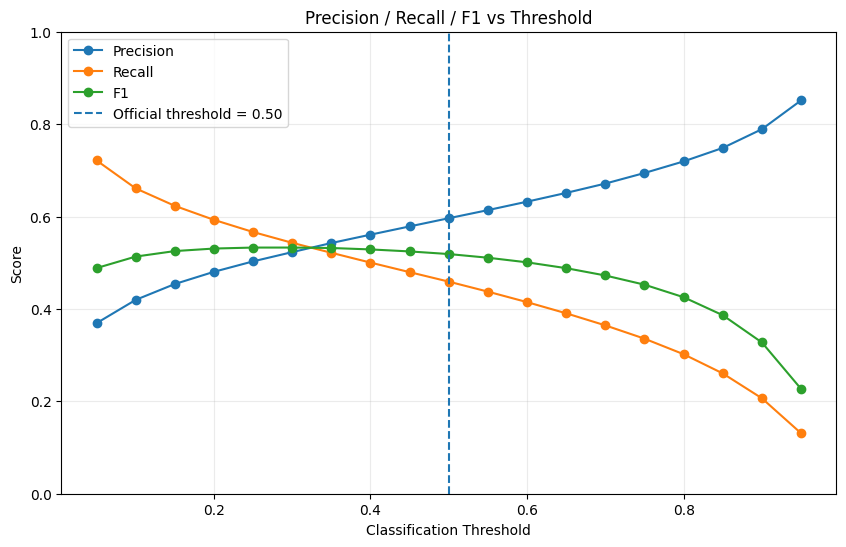

In [12]:
# The threshold sweep is diagnostic only.
# It does not replace the official 0.50 comparison threshold.

display(threshold_analysis)

plt.figure(figsize=(10, 6))
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["precision"],
    marker="o",
    label="Precision",
)
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["recall"],
    marker="o",
    label="Recall",
)
plt.plot(
    threshold_analysis["threshold"],
    threshold_analysis["f1"],
    marker="o",
    label="F1",
)
plt.axvline(
    0.50,
    linestyle="--",
    label="Official threshold = 0.50",
)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Class Balance

,fold,horizon,observations,actual_peaks,actual_peak_rate_pct
0,fold_2023,1,52416,5743,10.956578
1,fold_2023,2,52416,5743,10.956578
2,fold_2023,3,52416,5743,10.956578
3,fold_2023,4,52416,5743,10.956578
4,fold_2023,5,52416,5743,10.956578
5,fold_2023,6,52416,5743,10.956578
6,fold_2023,7,52416,5743,10.956578
7,fold_2023,8,52416,5743,10.956578
8,fold_2023,9,52416,5743,10.956578
9,fold_2023,10,52416,5743,10.956578


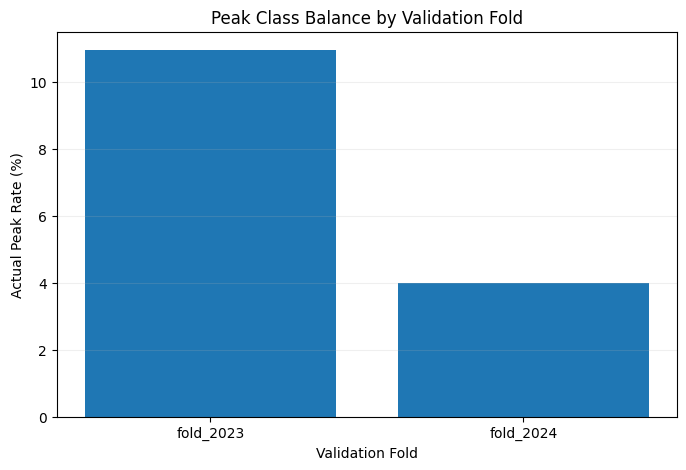

In [13]:
# Actual Peak prevalence by fold and horizon.
display(class_balance)

fold_balance = (
    predictions.groupby("fold", observed=True)["actual"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))
plt.bar(
    fold_balance.index.astype(str),
    fold_balance.values,
)
plt.xlabel("Validation Fold")
plt.ylabel("Actual Peak Rate (%)")
plt.title("Peak Class Balance by Validation Fold")
plt.grid(axis="y", alpha=0.2)
plt.show()


## PR-AUC by Forecast Horizon

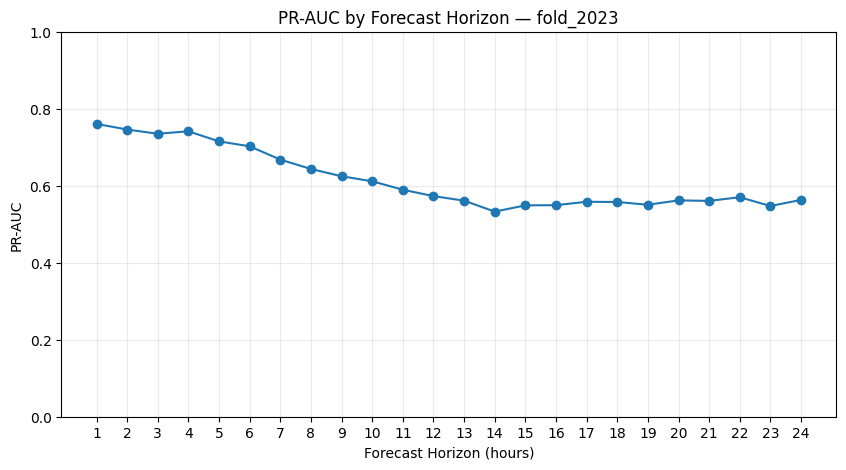

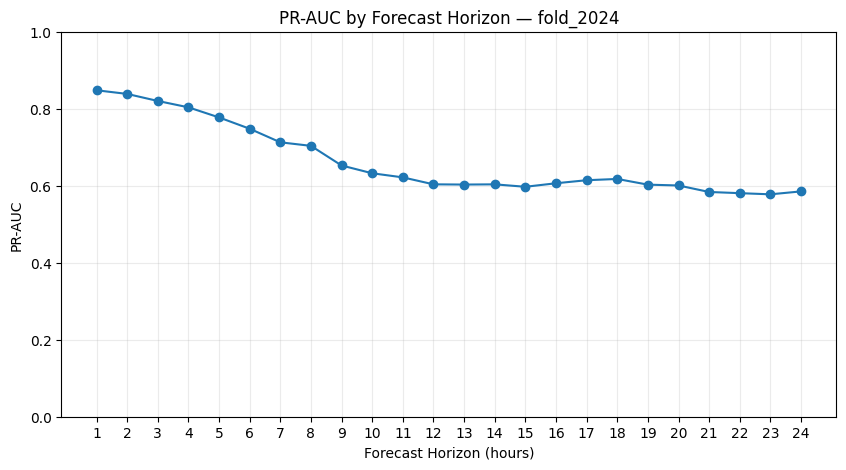

In [14]:
for fold, group in horizon_metrics.groupby("fold", observed=True):
    group = group.sort_values("horizon")

    plt.figure(figsize=(10, 5))
    plt.plot(
        group["horizon"],
        group["pr_auc"],
        marker="o",
    )
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("PR-AUC")
    plt.title(f"PR-AUC by Forecast Horizon — {fold}")
    plt.xticks(range(1, 25))
    plt.ylim(0, 1)
    plt.grid(alpha=0.25)
    plt.show()


## Peak Rate and False Negative Rate by FSA

,fold,fsa,peak_rate_pct
0,fold_2023,L4T,1.900183
1,fold_2023,M5R,1.968864
2,fold_2023,M5S,1.579670
3,fold_2023,M6G,5.574634
4,fold_2023,M9R,3.363954
5,fold_2023,M9W,51.404151
6,fold_2024,L4T,2.796804
7,fold_2024,M5R,1.678082
8,fold_2024,M5S,1.358447
9,fold_2024,M6G,3.641553


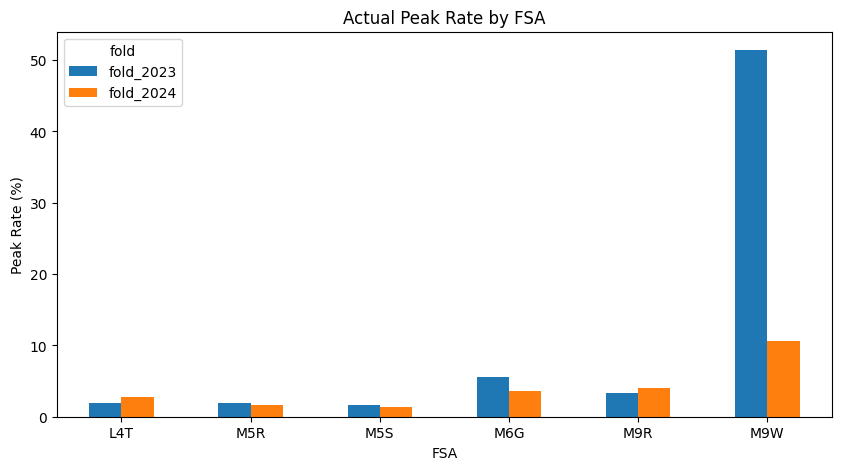

In [15]:
# Peak prevalence by FSA and fold.

fsa_peak_rate = (
    predictions
    .groupby(["fold", "fsa"], observed=True)["actual"]
    .mean()
    .mul(100)
    .reset_index(name="peak_rate_pct")
)

display(fsa_peak_rate)

pivot_peak_rate = fsa_peak_rate.pivot(
    index="fsa",
    columns="fold",
    values="peak_rate_pct",
)

pivot_peak_rate.plot(
    kind="bar",
    figsize=(10, 5),
)
plt.xlabel("FSA")
plt.ylabel("Peak Rate (%)")
plt.title("Actual Peak Rate by FSA")
plt.xticks(rotation=0)
plt.show()


,fold,fsa,actual_peaks,missed_peaks,missed_peak_rate_pct
0,fold_2023,L4T,3984,1931,48.468876
1,fold_2023,M5R,4128,1816,43.992248
2,fold_2023,M5S,3312,963,29.076087
3,fold_2023,M6G,11688,6182,52.891855
4,fold_2023,M9R,7053,3277,46.462498
5,fold_2023,M9W,107776,78798,73.112752
6,fold_2024,L4T,5880,856,14.557823
7,fold_2024,M5R,3528,520,14.739229
8,fold_2024,M5S,2856,638,22.338936
9,fold_2024,M6G,7656,1098,14.341693


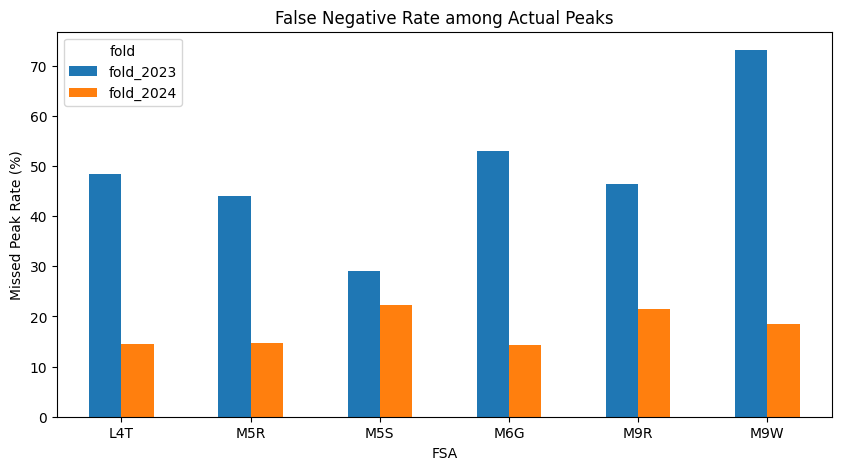

In [16]:
# False Negative Rate among actual Peaks by FSA.

peak_rows = predictions[predictions["actual"] == 1].copy()
peak_rows["missed_peak"] = (
    peak_rows["predicted"] == 0
).astype("int8")

missed_peak_by_fsa = (
    peak_rows
    .groupby(["fold", "fsa"], observed=True)
    .agg(
        actual_peaks=("actual", "size"),
        missed_peaks=("missed_peak", "sum"),
    )
    .reset_index()
)

missed_peak_by_fsa["missed_peak_rate_pct"] = (
    missed_peak_by_fsa["missed_peaks"]
    / missed_peak_by_fsa["actual_peaks"]
    * 100
)

display(missed_peak_by_fsa)

missed_pivot = missed_peak_by_fsa.pivot(
    index="fsa",
    columns="fold",
    values="missed_peak_rate_pct",
)

missed_pivot.plot(
    kind="bar",
    figsize=(10, 5),
)
plt.xlabel("FSA")
plt.ylabel("Missed Peak Rate (%)")
plt.title("False Negative Rate among Actual Peaks")
plt.xticks(rotation=0)
plt.show()


## Monthly Performance

In [17]:
predictions["month"] = (
    predictions["forecast_origin"]
    .dt.to_period("M")
    .astype(str)
)

monthly_rows = []

for (fold, month), group in predictions.groupby(
    ["fold", "month"],
    observed=True,
):
    actual = group["actual"].to_numpy()
    predicted = group["predicted"].to_numpy()
    probability = group["probability"].to_numpy()

    from sklearn.metrics import (
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
    )

    monthly_rows.append(
        {
            "fold": fold,
            "month": month,
            "observations": len(group),
            "actual_peak_rate_pct": actual.mean() * 100,
            "precision": precision_score(
                actual, predicted, zero_division=0
            ),
            "recall": recall_score(
                actual, predicted, zero_division=0
            ),
            "f1": f1_score(
                actual, predicted, zero_division=0
            ),
            "pr_auc": (
                average_precision_score(actual, probability)
                if len(np.unique(actual)) == 2
                else np.nan
            ),
        }
    )

monthly_metrics = pd.DataFrame(monthly_rows)
display(monthly_metrics)


,fold,month,observations,actual_peak_rate_pct,precision,recall,f1,pr_auc
0,fold_2023,2023-01,107136,9.340464,0.698620,0.278205,0.397942,0.584588
1,fold_2023,2023-02,96768,11.170015,0.738897,0.241650,0.364194,0.604755
2,fold_2023,2023-03,107136,17.474052,0.663886,0.450617,0.536846,0.628525
3,fold_2023,2023-04,103680,11.009838,0.981481,0.018572,0.036454,0.695085
4,fold_2023,2023-05,107136,11.741151,0.737601,0.231735,0.352671,0.658535
5,fold_2023,2023-06,103680,2.681327,0.360544,0.114388,0.173676,0.236513
6,fold_2023,2023-07,107136,7.707027,0.439018,0.218845,0.292088,0.362184
7,fold_2023,2023-08,107136,2.545363,0.278332,0.112578,0.160313,0.185994
8,fold_2023,2023-09,103680,19.785880,0.815191,0.466169,0.593146,0.747135
9,fold_2023,2023-10,107136,12.914427,0.932121,0.055580,0.104904,0.784449


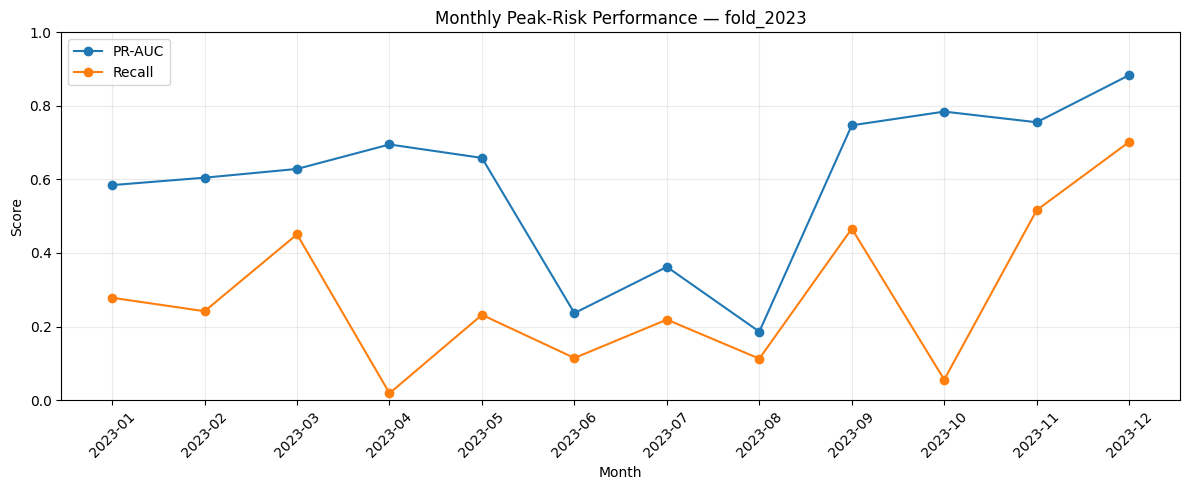

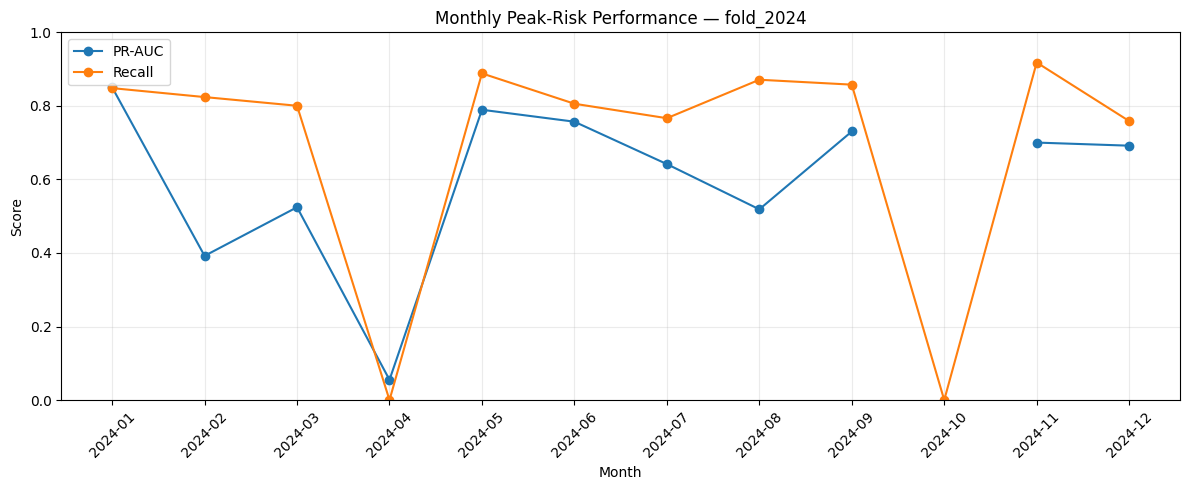

In [18]:
for fold, group in monthly_metrics.groupby("fold", observed=True):
    plt.figure(figsize=(12, 5))
    plt.plot(
        group["month"],
        group["pr_auc"],
        marker="o",
        label="PR-AUC",
    )
    plt.plot(
        group["month"],
        group["recall"],
        marker="o",
        label="Recall",
    )
    plt.xlabel("Month")
    plt.ylabel("Score")
    plt.title(f"Monthly Peak-Risk Performance — {fold}")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## Probability Distribution

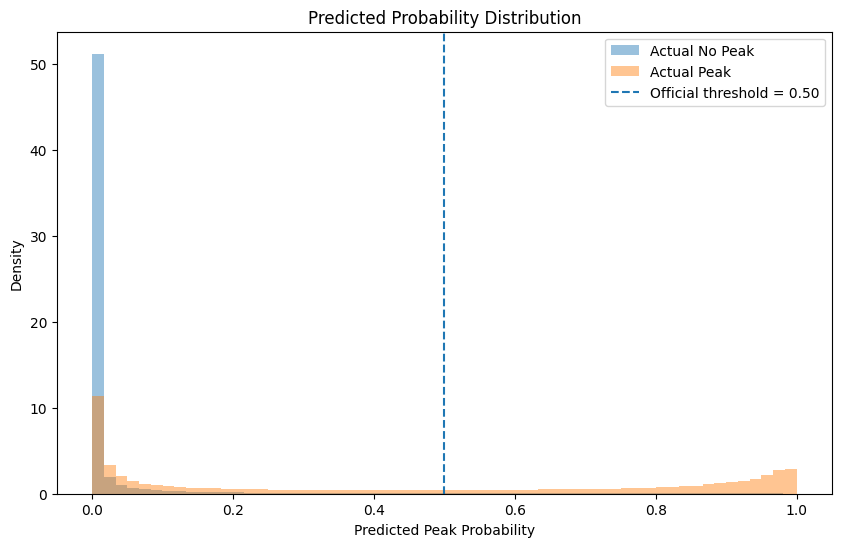

In [19]:
no_peak = predictions.loc[
    predictions["actual"] == 0,
    "probability",
]

peak = predictions.loc[
    predictions["actual"] == 1,
    "probability",
]

plt.figure(figsize=(10, 6))
plt.hist(
    no_peak,
    bins=60,
    density=True,
    alpha=0.45,
    label="Actual No Peak",
)
plt.hist(
    peak,
    bins=60,
    density=True,
    alpha=0.45,
    label="Actual Peak",
)
plt.axvline(
    0.50,
    linestyle="--",
    label="Official threshold = 0.50",
)
plt.xlabel("Predicted Peak Probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()


## Calibration / Brier Diagnostic

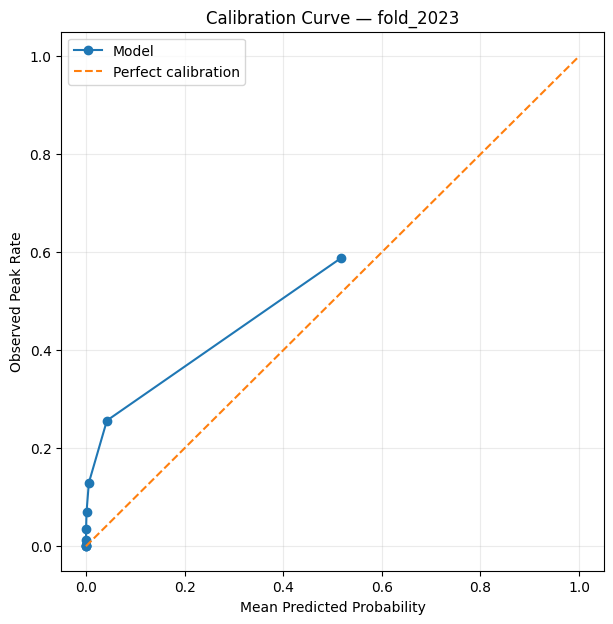

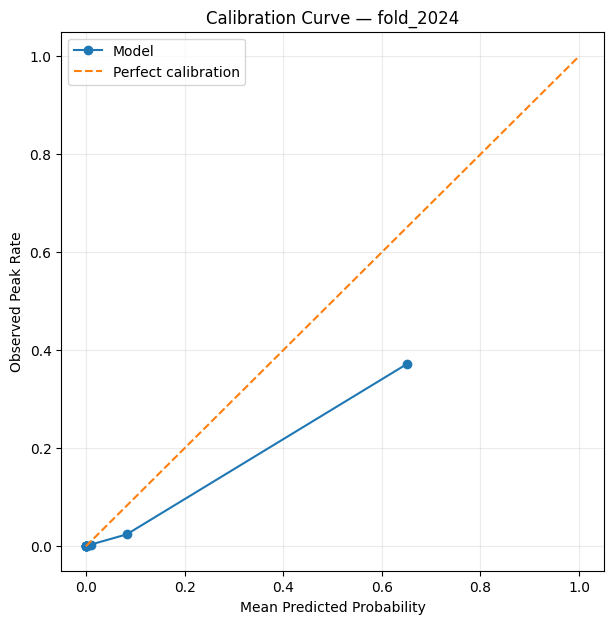

In [20]:
# Reliability curve by fold.
# Calibration and Brier score are supplementary diagnostics, not the common
# model-selection metric.

for fold, group in predictions.groupby("fold", observed=True):
    fraction_of_positives, mean_predicted = calibration_curve(
        group["actual"],
        group["probability"],
        n_bins=10,
        strategy="quantile",
    )

    plt.figure(figsize=(7, 7))
    plt.plot(
        mean_predicted,
        fraction_of_positives,
        marker="o",
        label="Model",
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Peak Rate")
    plt.title(f"Calibration Curve — {fold}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## Actual Peak Detection Timeline

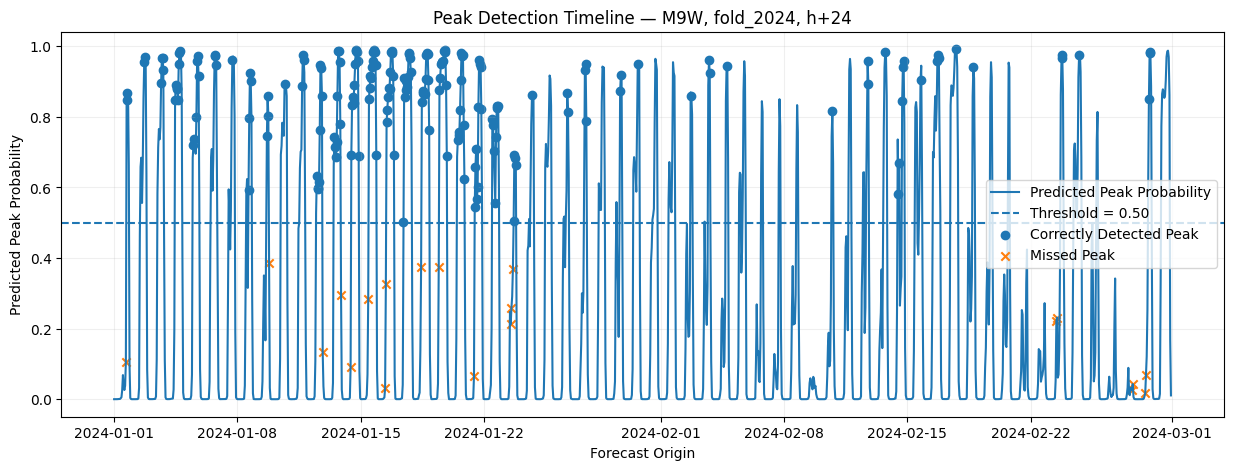

In [21]:
# Representative h+24 M9W timeline.
# Correctly detected and missed Peaks are displayed against predicted risk.

timeline = (
    predictions[
        (predictions["fold"] == "fold_2024")
        & (predictions["fsa"] == "M9W")
        & (predictions["horizon"] == 24)
    ]
    .sort_values("forecast_origin")
    .head(24 * 60)
    .copy()
)

plt.figure(figsize=(15, 5))
plt.plot(
    timeline["forecast_origin"],
    timeline["probability"],
    label="Predicted Peak Probability",
)
plt.axhline(
    0.50,
    linestyle="--",
    label="Threshold = 0.50",
)

correct = timeline[
    (timeline["actual"] == 1)
    & (timeline["predicted"] == 1)
]
missed = timeline[
    (timeline["actual"] == 1)
    & (timeline["predicted"] == 0)
]

plt.scatter(
    correct["forecast_origin"],
    correct["probability"],
    marker="o",
    label="Correctly Detected Peak",
)
plt.scatter(
    missed["forecast_origin"],
    missed["probability"],
    marker="x",
    label="Missed Peak",
)

plt.xlabel("Forecast Origin")
plt.ylabel("Predicted Peak Probability")
plt.title("Peak Detection Timeline — M9W, fold_2024, h+24")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Feature Importance

,feature,importance
0,target_hour_sin,0.183296
1,target_hour,0.129320
2,target_season_Summer,0.059518
3,origin__Temp (°C),0.048384
4,target_lag_24h,0.048136
5,target_month_cos,0.044291
6,target_month_sin,0.040973
7,target_season_Winter,0.038279
8,fsa_M9W,0.037249
9,target_hour_cos,0.037018


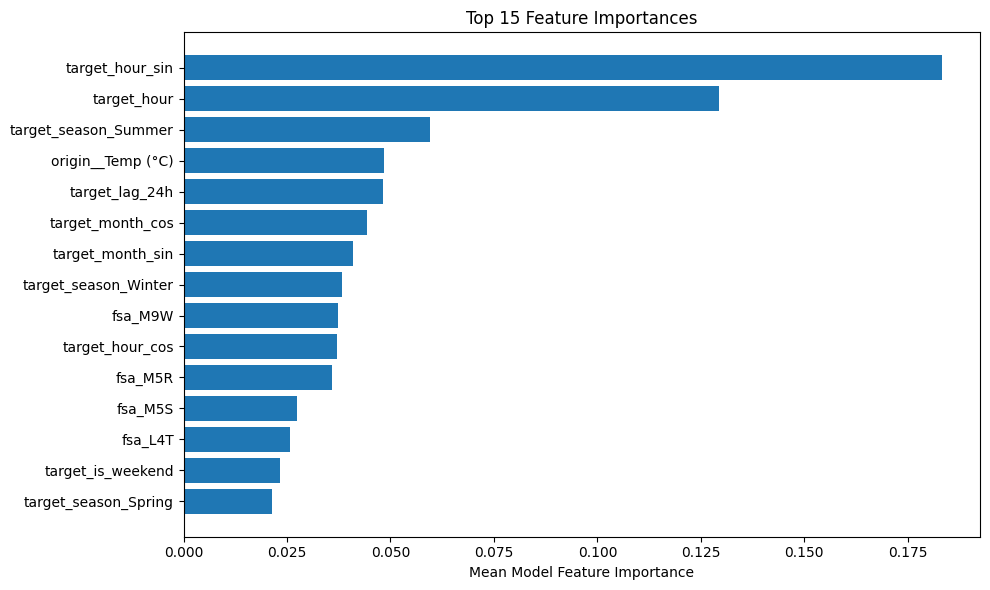

In [22]:
display(feature_importance.head(20))

plot_data = (
    feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["feature"],
    plot_data["importance"],
)
plt.xlabel("Mean Model Feature Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


## Additional Model Stability Diagnostics

The following analyses mirror the additional diagnostics used for the Random Forest Classifier. They do **not** retrain XGBoost and use only the saved validation predictions already loaded in this notebook.

They evaluate:

1. model performance with and without the M9W-2023 structural stress case;
2. macro-average performance across FSAs;
3. threshold stability separately by validation fold.

In [ ]:
# ============================================================
# Additional diagnostic 1
# Global metrics with and without M9W-2023
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
)

def evaluate_subset(frame, label):
    y_true = frame["actual"].astype(int)
    y_pred = frame["predicted"].astype(int)
    y_prob = frame["probability"].astype(float)

    return {
        "segment": label,
        "observations": len(frame),
        "peak_rate_pct": y_true.mean() * 100,
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "pr_auc": (
            average_precision_score(
                y_true,
                y_prob,
            )
            if y_true.nunique() == 2
            else np.nan
        ),
        "roc_auc": (
            roc_auc_score(
                y_true,
                y_prob,
            )
            if y_true.nunique() == 2
            else np.nan
        ),
        "brier_score": brier_score_loss(
            y_true,
            y_prob,
        ),
    }


m9w_2023_mask = (
    (predictions["fold"] == "fold_2023")
    &
    (predictions["fsa"] == "M9W")
)

comparison = pd.DataFrame(
    [
        evaluate_subset(
            predictions,
            "All validation data",
        ),
        evaluate_subset(
            predictions.loc[~m9w_2023_mask],
            "Excluding M9W-2023",
        ),
        evaluate_subset(
            predictions.loc[m9w_2023_mask],
            "M9W-2023 only",
        ),
    ]
)

display(comparison)


### Macro-Average Performance Across FSAs

In [ ]:
# ============================================================
# Additional diagnostic 2
# Macro-average metrics across FSA
# ============================================================

macro_fsa = (
    fsa_metrics
    .groupby(
        "fold",
        observed=True,
    )
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1", "mean"),
        macro_pr_auc=("pr_auc", "mean"),
        macro_roc_auc=("roc_auc", "mean"),
        macro_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
    )
    .reset_index()
)

display(macro_fsa)


In [ ]:
# Plot macro-average metrics across FSAs.

macro_plot = macro_fsa.set_index("fold")[
    [
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "macro_pr_auc",
    ]
]

macro_plot.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.ylabel("Score")
plt.title(
    "XGBoost Classifier — "
    "Macro-Average Performance Across FSAs"
)

plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### Threshold Stability by Validation Fold

In [ ]:
# ============================================================
# Additional diagnostic 3
# Threshold analysis by validation fold
# ============================================================

threshold_values = np.arange(
    0.05,
    0.96,
    0.05,
)

threshold_fold_rows = []

for fold, group in predictions.groupby(
    "fold",
    observed=True,
):

    y_true = group["actual"].astype(int)
    y_prob = group["probability"].astype(float)

    for threshold in threshold_values:

        y_pred = (
            y_prob >= threshold
        ).astype(int)

        threshold_fold_rows.append(
            {
                "fold": fold,
                "threshold": threshold,
                "precision": precision_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
                "recall": recall_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
                "f1": f1_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
            }
        )

threshold_by_fold = pd.DataFrame(
    threshold_fold_rows
)

display(threshold_by_fold)


In [ ]:
# Plot threshold diagnostics separately for each validation fold.

for fold, group in threshold_by_fold.groupby(
    "fold",
    observed=True,
):

    plt.figure(figsize=(10, 5))

    plt.plot(
        group["threshold"],
        group["precision"],
        marker="o",
        label="Precision",
    )

    plt.plot(
        group["threshold"],
        group["recall"],
        marker="o",
        label="Recall",
    )

    plt.plot(
        group["threshold"],
        group["f1"],
        marker="o",
        label="F1",
    )

    plt.axvline(
        0.50,
        linestyle="--",
        label="Official threshold = 0.50",
    )

    best_row = group.loc[
        group["f1"].idxmax()
    ]

    plt.axvline(
        best_row["threshold"],
        linestyle=":",
        label=(
            "Best F1 threshold = "
            f"{best_row['threshold']:.2f}"
        ),
    )

    plt.xlabel("Classification Threshold")
    plt.ylabel("Score")

    plt.title(
        f"XGBoost — Threshold Diagnostics ({fold})"
    )

    plt.ylim(0, 1)

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


In [ ]:
# Summarize the F1-optimal diagnostic threshold by fold.

best_threshold_by_fold = (
    threshold_by_fold
    .loc[
        threshold_by_fold
        .groupby("fold")["f1"]
        .idxmax()
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)

display(best_threshold_by_fold)
